In [1]:
! pip3 install -r requirements.txt

In [2]:
from fastai.vision.all import *
from fastcore.all import *

Test that we can open an image

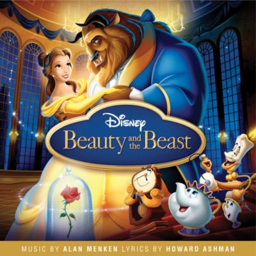

In [3]:
img_ex = 'dataset/cd/1991/Beauty and the Beast_1991.jpg'
im = Image.open(img_ex)
im.to_thumb(256,256)

In [4]:
formats = ['vinyl', 'cassette_tape', 'cd', 'digital_download', 'streaming']

for f in formats:
    dest = f'dataset/{f}'
    resize_images(dest, max_size=400, dest=dest, recurse=True)

In [5]:
def get_format_label(path):
    """Get the format label (the grandparent folder) from image path"""
    return path.parent.parent.name

def get_grouped_format(path):
    """
    Group formats into 3 categories based on form factor:
    - vinyl: large physical format
    - physical_compact: small physical format (cassette_tape and cd)
    - digital: digital download and streaming
    """
    format = get_format_label(path)

    if format == 'vinyl':
        return 'vinyl'
    elif format in ['cassette_tape', 'cd']:
        return 'physical_compact'
    elif format in ['digital_download', 'streaming']:
        return 'digital'
    else:
        return format  # fallback

Train the model

/home/apchap/Documents/Code/album-art-analysis/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


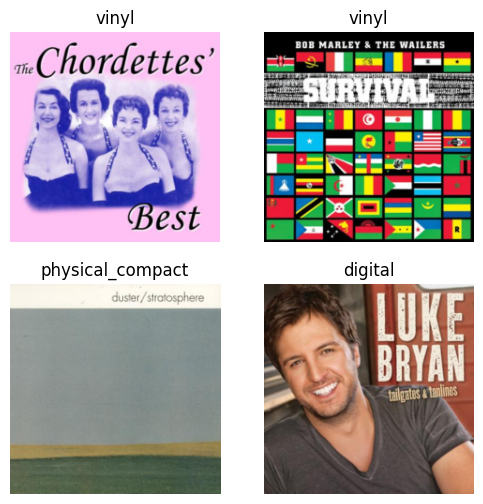

In [6]:
path = 'dataset'

dls3 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_grouped_format,
    item_tfms=[Resize(224, method='squish')]
).dataloaders(path, bs=16)

dls3.show_batch(max_n=4)

<div></div>

SuggestedLRs(slide=0.004365158267319202, valley=4.365158383734524e-05)

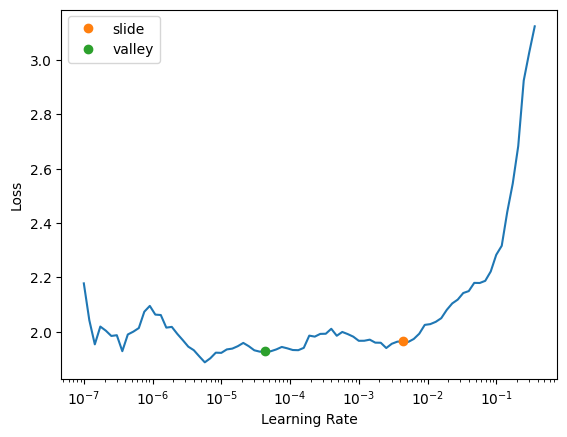

In [7]:
learn3 = vision_learner(dls3, resnet18, metrics=error_rate)
lr3 = learn3.lr_find(suggest_funcs=(slide, valley))
lr3

Verify base model performance

In [8]:
base_model3_perf = learn3.validate()
base_model3_perf  # loss, error rate

[3.972909927368164, 0.5454545617103577]

In [9]:
learn3.fine_tune(4, base_lr=0.00025)

epoch,train_loss,valid_loss,error_rate,time
0,1.911358,1.251320,0.572391,00:13


epoch,train_loss,valid_loss,error_rate,time
0,1.662897,1.162254,0.535354,00:18
1,1.519983,1.090392,0.494949,00:18
2,1.228714,1.076090,0.481481,00:18
3,1.192451,1.075705,0.484848,00:18


Make predictions

This is a vinyl.
{'digital': 0.35157933831214905, 'physical_compact': 0.04814685881137848, 'vinyl': 0.6002737879753113}


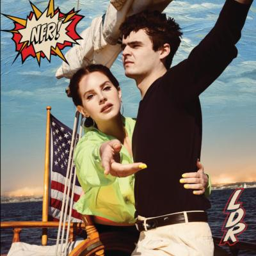

In [10]:
img_ex = 'dataset/streaming/2019/Norman Fucking Rockwell!_2019.jpg'
img_ex
pred, _, probs = learn3.predict(PILImage.create(img_ex))
print(f'This is a {pred}.')
print(dict(zip(learn3.dls.vocab, map(float, probs))))
im = Image.open(img_ex)
im.to_thumb(256, 256)

Export model

In [11]:
from pathlib import Path
Path('models').mkdir(exist_ok=True)

In [12]:
learn3.export('models/model_3format.pkl')
print('Exported 3-format model')

Exported 3-format model


Train 5 format model

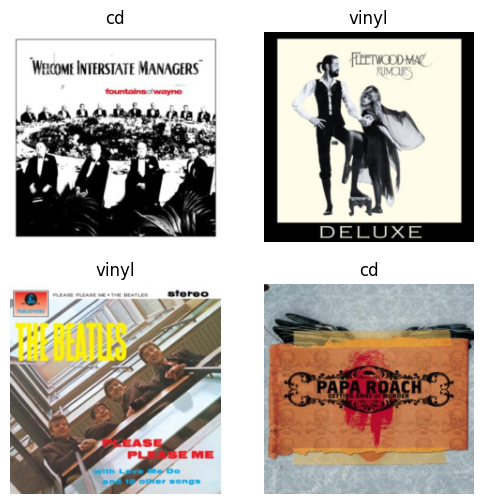

In [13]:
dls5 = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=get_format_label,
    item_tfms=[Resize(224, method='squish')]
).dataloaders(path, bs=16)

dls5.show_batch(max_n=4)

<div></div>

SuggestedLRs(slide=0.009120108559727669, valley=0.0010000000474974513)

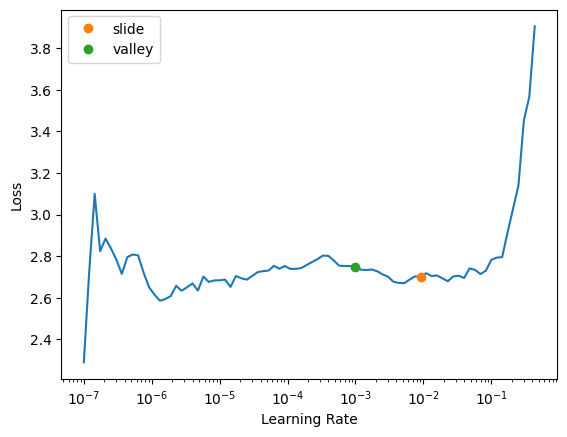

In [14]:
learn5= vision_learner(dls5, resnet18, metrics=error_rate)
learn5.lr_find(suggest_funcs=(slide, valley))

In [15]:
base_model5_perf = learn5.validate()
base_model5_perf  # loss, error rate

[3.231585741043091, 0.7205387353897095]

In [16]:
learn5.fine_tune(4, base_lr=0.002)

epoch,train_loss,valid_loss,error_rate,time
0,2.372617,1.729437,0.569024,00:12


epoch,train_loss,valid_loss,error_rate,time
0,1.560089,1.493739,0.468013,00:17
1,1.148643,1.564476,0.461279,00:18
2,0.647346,1.472147,0.441077,00:17
3,0.355681,1.439743,0.417508,00:17


In [17]:
learn5.export('models/model_5format.pkl')
print('Exported 5-format model')

Exported 5-format model


In [18]:
learn5.model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T